# ETF allocation: how much is the signal, and how much is the weighting

[`14_backtest`](14_backtest.ipynb) traded every prediction set one way: pick the top k funds by
predicted score and hold them in equal weight. That rule makes one decision - **which** funds to
hold - and declines the other, which is **how much** of each. This notebook makes the second
decision six different ways on the same predictions and measures what it is worth.

The reason to ask is that the two decisions are not obviously comparable in size. A weighting
scheme can only redistribute capital among funds the signal already chose; it cannot put money
into a fund the ranking left out. So the question is not whether a better allocator helps, it is
whether the help is on the scale of the difference between model families, or an order of
magnitude below it.

**The concentration is swept alongside the allocator, because the two interact.** At a top-5
selection there is little for an allocator to do and the schemes converge on each other; at
top-20 the basket holds funds with genuinely different volatilities and the schemes separate.
Reading either axis alone would attribute the interaction to whichever one was varied.

**Learning objectives**

- Say what a portfolio allocator can and cannot change about a strategy built on a ranking.
- Compare equal-weight, score-weighted, inverse-volatility, risk-parity, mean-variance and
  hierarchical risk parity on one set of predictions.
- Read an allocator comparison against the spread across prediction sources, rather than on its
  own scale.
- Say why the concentration level and the allocator have to be swept together.

**Book reference**: Chapter 17, Sections 17.2 to 17.8.

**Prerequisites**: [`14_backtest`](14_backtest.ipynb), whose signal-stage results select the
prediction sets this sweep starts from.

**What it writes**: one row in `backtest_runs` per prediction set, concentration level and
allocator, at `stage='allocation'`. [`16_costs`](16_costs.ipynb) takes the leading combinations
from here into the cost sweep.

In [1]:
"""Sweep portfolio allocators and concentration levels over the leading ETF predictions."""

import json
import time
import warnings

import plotly.graph_objects as go
import polars as pl

from case_studies.research import open_study, split_retired_members
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec, strategy_view
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
    resolve_best_backtest_runs,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.style import COLORS, show_plotly_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_PREDICTIONS: int | None = None
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace (`tests/pm_helpers.py:954`). Without them the canonical
# branch regenerates in place, which needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## 1. Which predictions the sweep starts from

The prediction sets carried forward are the leaders **by signal-stage Sharpe**, not by
information coefficient. That is the selection rule the case study states, and
[`14_backtest`](14_backtest.ipynb) is where the two orderings were shown to disagree: a ranking
that correlates well with returns across the whole cross-section is not the same thing as a
ranking whose head is worth holding.

`checkpoints_per_config` caps how many checkpoints of a single configuration may advance. Without
it a family that saves eight checkpoints of one network would fill the shortlist with eight
near-identical variants of one model, and the allocator comparison below would be measured almost
entirely on that one prediction.

In [3]:
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
if not LABEL:
    LABEL = bt_config.primary_label
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

Case study: etfs, label: fwd_ret_21d


**The population the ranking runs over.** A model notebook that refits publishes a second
generation under the same population name, and the generation it replaced stays in the registry:
complete, current under a schema version that has not moved, and carrying whatever backtests the
previous sweep registered for it. Ranking over both lets an identity its own publisher has
retired take a slot from a live one, which is not a reporting error - the retired row is what
every stage after this one then builds on. `split_retired_members` reads the population lineage,
and the surviving members are what every reader below is scoped to.

In [4]:
LIVE_PREDICTIONS = (
    split_retired_members(
        open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None),
        load_prediction_index(CASE_STUDY_ID, label=LABEL, split="validation"),
    )
    .live["prediction_hash"]
    .to_list()
)
if not LIVE_PREDICTIONS:
    raise RuntimeError(
        f"no live prediction sets for {CASE_STUDY_ID}/{LABEL}/validation; run 14_backtest first"
    )
print(f"Live prediction sets: {len(LIVE_PREDICTIONS):,}")

Live prediction sets: 257


In [5]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
    prediction_hashes=set(LIVE_PREDICTIONS),
)
if top_preds.is_empty():
    raise RuntimeError(
        "no signal-stage backtests are registered, so there is nothing to advance; "
        "run 14_backtest first"
    )
print(f"{len(top_preds)} prediction sets advance, ranked by equal-weight top-k Sharpe:")
top_preds.select("source", "sharpe")

10 prediction sets advance, ranked by equal-weight top-k Sharpe:


source,sharpe
str,f64
"""gbm/default_mae""",0.829972
"""deep_learning/lstm_h64""",0.82009
"""deep_learning/tsmixer""",0.746694
"""tabular_dl/tabm_m""",0.70409
"""tabular_dl/tabm_s""",0.698568
"""latent_factors/cae""",0.675562
"""gbm/default_huber""",0.658661
"""gbm/leaves_15_mae""",0.636077
"""gbm/leaves_63_huber""",0.619682


## 2. The sweep

Every advancing prediction, crossed with every concentration level and every allocator. As in the
signal stage this is orchestration over one `run_backtest` call: the allocator travels inside the
strategy specification, so it lands in the backtest hash and a combination already registered is
not recomputed.

In [6]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)

print(f"Prices: {len(prices):,} rows, {n_assets} tradeable funds")
print(f"Concentration grid: top_k in {TOP_K_VALUES}")
print(f"Allocators ({len(ALLOC_CONFIGS)}): {', '.join(a['method'] for a in ALLOC_CONFIGS)}")
print(
    f"Grid: {len(top_preds)} predictions x {len(TOP_K_VALUES)} concentrations x "
    f"{len(ALLOC_CONFIGS)} allocators = {n_total} backtests"
)

Prices: 198,877 rows, 100 tradeable funds
Concentration grid: top_k in [5, 10, 20]
Allocators (6): score_weighted, inverse_vol, risk_parity, mvo_ledoit_wolf, hrp, conformal_weighted
Grid: 10 predictions x 3 concentrations x 6 allocators = 180 backtests


Mean-variance optimization is the one allocator whose cost is not bounded by the grid: it inverts
a covariance matrix per rebalance, and on a wide basket that is where the sweep's time goes. The
loop measures its first fit, projects the remainder, and drops it from the rest of the grid if
that projection exceeds the budget - reporting that it did, because an allocator silently absent
from the comparison below would read as one that was tried and lost.

Two facts, and a reader needs both: what the **stage** holds before this run, and what **this
execution** did. `run_backtest` returns a cached result and a fresh fit through the same call,
so a warm re-run would otherwise report a completed sweep in no time at all - a wrong number
that looks exactly like a right one - while reporting only what this run computed would make
that same re-run look like an empty stage.

In [7]:
BUDGET_SECONDS = 3600
MVO_METHODS = ("mvo", "mvo_ledoit_wolf")

n_done = 0
served = 0
failures = []
skip_mvo = False
sweep_start = time.monotonic()
registered_before = load_existing_backtest_hashes(CASE_STUDY_ID, stage="allocation")
print(f"Allocation-stage backtests already registered: {len(registered_before):,}")

for top_k in TOP_K_VALUES:
    print(f"\n--- top_k = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]
        predictions = read_predictions(CASE_STUDY_ID, pred_hash)

        for alloc in ALLOC_CONFIGS:
            alloc_name = alloc["method"]
            if skip_mvo and alloc_name in MVO_METHODS:
                continue
            n_done += 1

            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_hash,
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )

            started = time.monotonic()
            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                )
            except Exception as error:
                failures.append(
                    {
                        "top_k": top_k,
                        "source": source,
                        "allocator": alloc_name,
                        "error": f"{type(error).__name__}: {error}",
                    }
                )
                continue
            elapsed = time.monotonic() - started
            if result.backtest_hash in registered_before:
                served += 1

            if alloc_name in MVO_METHODS and not skip_mvo:
                remaining = len(top_preds) * len(TOP_K_VALUES) - 1
                projected = (time.monotonic() - sweep_start) + elapsed * remaining
                if projected > BUDGET_SECONDS:
                    skip_mvo = True
                    print(
                        f"    dropping {alloc_name} from the rest of the grid: "
                        f"projected {projected / 60:.0f} minutes against a "
                        f"{BUDGET_SECONDS / 60:.0f} minute budget"
                    )

            print(
                f"  [{n_done}/{n_total}] k={top_k} {source} x {alloc_name}: "
                f"Sharpe={result.metrics.get('sharpe', 0):+.3f}"
            )

print(
    f"\nSweep complete in {(time.monotonic() - sweep_start) / 60:.1f} minutes: "
    f"{n_done - served - len(failures)} computed, {served} served from the registry, "
    f"{len(failures)} failed"
)
if failures:
    failure_frame = pl.DataFrame(failures)
    print(f"{failure_frame.height} backtests raised. Distinct causes:")
    print(failure_frame.group_by("error").len().sort("len", descending=True))
else:
    print("no backtest raised")

Allocation-stage backtests already registered: 180

--- top_k = 5 ---
  SKIP backtest (complete (hash=9066830a05eb)) — reusing cached result
  [1/180] k=5 gbm/default_mae x score_weighted: Sharpe=+0.742
  SKIP backtest (complete (hash=9725639de4ea)) — reusing cached result
  [2/180] k=5 gbm/default_mae x inverse_vol: Sharpe=+0.801
  SKIP backtest (complete (hash=59e890398b7f)) — reusing cached result
  [3/180] k=5 gbm/default_mae x risk_parity: Sharpe=+0.774
  SKIP backtest (complete (hash=e6ebf2f4b718)) — reusing cached result
  [4/180] k=5 gbm/default_mae x mvo_ledoit_wolf: Sharpe=+0.363
  SKIP backtest (complete (hash=e85a0e16bd2d)) — reusing cached result
  [5/180] k=5 gbm/default_mae x hrp: Sharpe=+0.711
  SKIP backtest (complete (hash=5acdc009ed83)) — reusing cached result
  [6/180] k=5 gbm/default_mae x conformal_weighted: Sharpe=+0.715


  [7/180] k=5 deep_learning/lstm_h64 x score_weighted: Sharpe=+0.571


  [8/180] k=5 deep_learning/lstm_h64 x inverse_vol: Sharpe=+0.839


  [9/180] k=5 deep_learning/lstm_h64 x risk_parity: Sharpe=+0.818


  [10/180] k=5 deep_learning/lstm_h64 x mvo_ledoit_wolf: Sharpe=+0.576


...

  [155/180] k=20 latent_factors/cae x hrp: Sharpe=+0.486


  [156/180] k=20 latent_factors/cae x conformal_weighted: Sharpe=+0.498
  SKIP backtest (complete (hash=5cfd44b55c7c)) — reusing cached result
  [157/180] k=20 gbm/default_huber x score_weighted: Sharpe=+0.565
  SKIP backtest (complete (hash=9820bbdb036a)) — reusing cached result
  [158/180] k=20 gbm/default_huber x inverse_vol: Sharpe=+0.651
  SKIP backtest (complete (hash=75d8f860c63a)) — reusing cached result
  [159/180] k=20 gbm/default_huber x risk_parity: Sharpe=+0.648
  SKIP backtest (complete (hash=d611f0ffca43)) — reusing cached result
  [160/180] k=20 gbm/default_huber x mvo_ledoit_wolf: Sharpe=+0.376
  SKIP backtest (complete (hash=918a05b874ff)) — reusing cached result
  [161/180] k=20 gbm/default_huber x hrp: Sharpe=+0.598
  SKIP backtest (complete (hash=8a474a4aca4d)) — reusing cached result
  [162/180] k=20 gbm/default_huber x conformal_weighted: Sharpe=+0.602


  SKIP backtest (complete (hash=2aa871103859)) — reusing cached result
  [163/180] k=20 gbm/leaves_15_mae x score_weighted: Sharpe=+0.469
  SKIP backtest (complete (hash=49f8e02e72c6)) — reusing cached result
  [164/180] k=20 gbm/leaves_15_mae x inverse_vol: Sharpe=+0.627
  SKIP backtest (complete (hash=419370cdb34d)) — reusing cached result
  [165/180] k=20 gbm/leaves_15_mae x risk_parity: Sharpe=+0.607
  SKIP backtest (complete (hash=f755fca1626a)) — reusing cached result
  [166/180] k=20 gbm/leaves_15_mae x mvo_ledoit_wolf: Sharpe=+0.216
  SKIP backtest (complete (hash=1f5a22e269f5)) — reusing cached result
  [167/180] k=20 gbm/leaves_15_mae x hrp: Sharpe=+0.566
  SKIP backtest (complete (hash=f6857a35e1f8)) — reusing cached result
  [168/180] k=20 gbm/leaves_15_mae x conformal_weighted: Sharpe=+0.558
  SKIP backtest (complete (hash=6a6d51fdc97c)) — reusing cached result
  [169/180] k=20 gbm/leaves_63_huber x score_weighted: Sharpe=+0.510
  SKIP backtest (complete (hash=fbb539a4f25a

  SKIP backtest (complete (hash=73dd4ace444d)) — reusing cached result
  [171/180] k=20 gbm/leaves_63_huber x risk_parity: Sharpe=+0.472
  SKIP backtest (complete (hash=729b6720041a)) — reusing cached result
  [172/180] k=20 gbm/leaves_63_huber x mvo_ledoit_wolf: Sharpe=+0.384
  SKIP backtest (complete (hash=dc92c0036b3b)) — reusing cached result
  [173/180] k=20 gbm/leaves_63_huber x hrp: Sharpe=+0.393
  SKIP backtest (complete (hash=bf929297341f)) — reusing cached result
  [174/180] k=20 gbm/leaves_63_huber x conformal_weighted: Sharpe=+0.450


  SKIP backtest (complete (hash=4150331b4a13)) — reusing cached result
  [175/180] k=20 gbm/leaves_31_huber x score_weighted: Sharpe=+0.460
  SKIP backtest (complete (hash=08ee71703ec5)) — reusing cached result
  [176/180] k=20 gbm/leaves_31_huber x inverse_vol: Sharpe=+0.634
  SKIP backtest (complete (hash=969aa4a9afaa)) — reusing cached result
  [177/180] k=20 gbm/leaves_31_huber x risk_parity: Sharpe=+0.601
  SKIP backtest (complete (hash=6ce206ceaa78)) — reusing cached result
  [178/180] k=20 gbm/leaves_31_huber x mvo_ledoit_wolf: Sharpe=+0.346
  SKIP backtest (complete (hash=09460796d529)) — reusing cached result
  [179/180] k=20 gbm/leaves_31_huber x hrp: Sharpe=+0.526
  SKIP backtest (complete (hash=7d067c701728)) — reusing cached result
  [180/180] k=20 gbm/leaves_31_huber x conformal_weighted: Sharpe=+0.539

Sweep complete in 2.0 minutes: 54 computed, 126 served from the registry, 0 failed
no backtest raised


## 3. What the allocator bought

From here the notebook queries the registry rather than the sweep it just ran, so the tables
describe the whole registered allocation stage and not the part this session happened to compute.

The comparison is restricted to this notebook's label and to the prediction sets that advanced.
Both restrictions matter: the registry accumulates rows from every label the case study has ever
swept, and from earlier sweeps whose shortlist differed, and folding those in would rank
allocators on a population that was never compared against itself.

In [8]:
explorer = BacktestExplorer(CASE_STUDY_ID)
alloc_comparison = explorer.compare_allocators(
    label=LABEL,
    prediction_hashes=top_preds["prediction_hash"].to_list(),
)
if alloc_comparison.is_empty():
    raise RuntimeError("the allocation stage registered no comparable rows")

### Against what the allocator changed, and what the prediction changed

The bar chart is the mean Sharpe per allocator. On its own it says which weighting scheme did
best on average, which is the less interesting half. The number printed beneath it is the one to
read it against: the spread across allocators next to the spread across the prediction sets they
were applied to. If the second is the larger, then which model produced the ranking decided more
than how the ranking was weighted, and no allocator rescues a prediction that had nothing in it.

In [9]:
alloc_comparison

allocator,n,avg_sharpe,best_sharpe,avg_max_dd
str,u32,f64,f64,f64
"""inverse_vol""",30,0.619582,0.839338,-0.386794
"""risk_parity""",30,0.603601,0.817546,-0.385283
"""hrp""",30,0.549217,0.801704,-0.379822
"""conformal_weighted""",30,0.542462,0.755856,-0.387264
"""score_weighted""",30,0.538821,0.754168,-0.412513
"""mvo_ledoit_wolf""",30,0.357925,0.663427,-0.570523


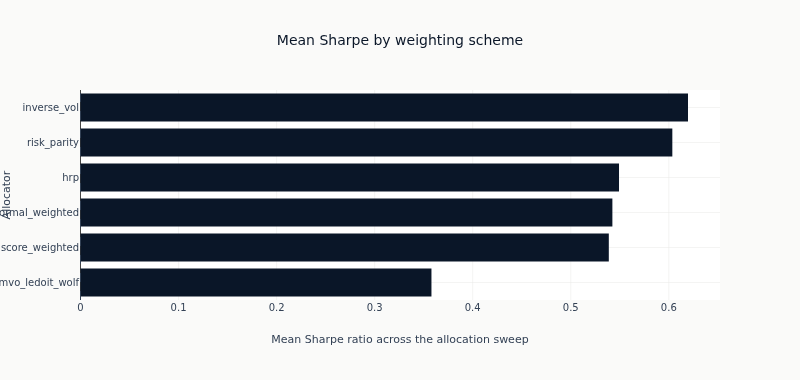

In [10]:
ordered = alloc_comparison.sort("avg_sharpe")
fig = go.Figure(
    go.Bar(
        x=ordered["avg_sharpe"].to_list(),
        y=ordered["allocator"].to_list(),
        orientation="h",
        marker_color=COLORS["blue"],
        showlegend=False,
    )
)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_xaxes(title_text="Mean Sharpe ratio across the allocation sweep")
fig.update_yaxes(title_text="Allocator")
fig.update_layout(
    title="Mean Sharpe by weighting scheme",
    height=380,
    width=800,
    margin=dict(t=90),
)
_span = ordered["avg_sharpe"]
show_plotly_with_alt(
    fig,
    "Horizontal bar chart of the mean Sharpe ratio of every allocation-stage backtest, one bar per "
    f"weighting scheme, with a dashed line at zero. Counted from the frame: {ordered.height} "
    f"allocators, mean Sharpe from {_span.min():+.3f} to {_span.max():+.3f}.",
)

The whole allocation stage for this label, with the concentration and the weighting scheme read
back out of each row's own stored specification. They are not columns of the registry: they are
part of what the backtest hash was taken over, so reading them from the spec is reading the same
declaration the run was identified by rather than a second copy of it.

It takes two readers, because neither carries both halves. `resolve_best_backtest_runs` returns
the stored specification and projects the model away; `BacktestExplorer.best` returns the model
and drops the specification. They share `backtest_hash`, which is what the join is on.

In [11]:
def _strategy_field(spec_json: str, section: str, field: str):
    """Read one declared field out of a registered backtest specification."""
    return strategy_view(json.loads(spec_json)).get(section, {}).get(field)


specs = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="allocation",
    top_n=100000,
    prediction_hashes=set(LIVE_PREDICTIONS),
)
if specs.is_empty():
    raise RuntimeError("the allocation stage registered no rows for this label")
allocation_rows = (
    specs.with_columns(
        pl.Series(
            "allocator",
            [_strategy_field(spec, "allocation", "method") for spec in specs["spec_json"]],
        ),
        pl.Series(
            "top_k",
            [_strategy_field(spec, "signal", "top_k") for spec in specs["spec_json"]],
            dtype=pl.Int64,
        ),
    )
    .drop("spec_json", "sharpe")
    .join(
        explorer.best(
            stage="allocation",
            top_n=100000,
            label=LABEL,
            prediction_hashes=LIVE_PREDICTIONS,
        ).select("backtest_hash", "source", "sharpe"),
        on="backtest_hash",
        how="inner",
    )
)
if allocation_rows.is_empty():
    raise RuntimeError("no allocation row carries both a stored specification and a source")

Beneath the spread comparison, the same rows crossed the other way: one row per concentration
level, one column per allocator. A weighting scheme has nothing to redistribute when the basket
is small, so the columns should converge at the tightest concentration and separate as the basket
widens - and where they do not, the allocator is responding to something other than how much the
holdings differ from each other.

In [12]:
by_source = allocation_rows.group_by("source").agg(pl.col("sharpe").mean().alias("avg_sharpe"))
allocator_span = _span.max() - _span.min()
source_span = by_source["avg_sharpe"].max() - by_source["avg_sharpe"].min()
print(f"spread in mean Sharpe across {ordered.height} allocators:         {allocator_span:.3f}")
print(f"spread in mean Sharpe across {by_source.height} prediction sources: {source_span:.3f}")
print(
    "the prediction moved performance more than the allocator did"
    if source_span > allocator_span
    else "the allocator moved performance more than the prediction did"
)

concentration = (
    allocation_rows.drop_nulls(["top_k", "allocator"])
    .group_by("top_k", "allocator")
    .agg(pl.col("sharpe").mean().alias("avg_sharpe"))
    .sort("top_k", "allocator")
)
if concentration.is_empty():
    raise RuntimeError("no allocation row declares both a concentration and an allocator")
print("\nMean Sharpe by concentration and allocator:")
print(concentration.pivot(on="allocator", index="top_k", values="avg_sharpe"))

spread in mean Sharpe across 6 allocators:         0.262
spread in mean Sharpe across 12 prediction sources: 0.181
the allocator moved performance more than the prediction did

Mean Sharpe by concentration and allocator:
shape: (3, 7)
┌───────┬─────────────────┬──────────┬─────────────┬────────────────┬─────────────┬────────────────┐
│ top_k ┆ conformal_weigh ┆ hrp      ┆ inverse_vol ┆ mvo_ledoit_wol ┆ risk_parity ┆ score_weighted │
│ ---   ┆ ted             ┆ ---      ┆ ---         ┆ f              ┆ ---         ┆ ---            │
│ i64   ┆ ---             ┆ f64      ┆ f64         ┆ ---            ┆ f64         ┆ f64            │
│       ┆ f64             ┆          ┆             ┆ f64            ┆             ┆                │
╞═══════╪═════════════════╪══════════╪═════════════╪════════════════╪═════════════╪════════════════╡
│ 5     ┆ 0.552718        ┆ 0.54706  ┆ 0.611396    ┆ 0.294421       ┆ 0.596467    ┆ 0.503979       │
│ 10    ┆ 0.526955        ┆ 0.517615 ┆ 0.592172    ┆ 0.320

### The leading combinations

In [13]:
explorer.best(stage="allocation", top_n=10, label=LABEL, prediction_hashes=LIVE_PREDICTIONS).select(
    "source", "signal_method", "sharpe", "cagr", "max_drawdown"
)

source,signal_method,sharpe,cagr,max_drawdown
str,str,f64,f64,f64
"""deep_learning/lstm_h64""","""equal_weight_top_k""",0.839338,0.15553,-0.329568
"""deep_learning/lstm_h64""","""equal_weight_top_k""",0.817546,0.148464,-0.335728
"""deep_learning/lstm_h64""","""equal_weight_top_k""",0.801704,0.143249,-0.317454
"""gbm/default_mae""","""equal_weight_top_k""",0.80105,0.146251,-0.421476
"""tabular_dl/tabm_m""","""equal_weight_top_k""",0.782921,0.107261,-0.339382
"""tabular_dl/tabm_s""","""equal_weight_top_k""",0.781756,0.134211,-0.396619
"""tabular_dl/tabm_m""","""equal_weight_top_k""",0.780541,0.111887,-0.349324
"""gbm/default_mae""","""equal_weight_top_k""",0.773599,0.138273,-0.42731
"""tabular_dl/tabm_s""","""equal_weight_top_k""",0.758106,0.125099,-0.405354


## 4. What to notice

**An allocator cannot choose an asset.** Every scheme here weights the same top-k basket, chosen
by the same predicted ranking, rebalanced on the same calendar. What separates two rows of the
comparison above is entirely how capital was split among funds the signal had already picked, so
whatever the allocator is worth is bounded above by how much the funds in that basket differ from
each other.

**The concentration is a portfolio decision made before the allocator sees anything.** Holding
five funds instead of twenty changes which funds are in the basket, how much of the ranking's
information is used, and how much any weighting scheme can move the result. It is swept here
rather than fixed because the answer to "does the allocator matter" is different at each level.

**Mean-variance is the one scheme whose cost scales with the basket.** Estimating a covariance
matrix from a rolling window and inverting it is where the sweep's time goes, and the estimation
error in that matrix is also why the theoretical advantage over a simpler scheme often does not
appear. The budget check above is an operational guard, not a judgement about the method.

**Known limitations.** Every Sharpe here is gross of the cost differences between schemes: a
scheme that rebalances weights within a stable basket trades more than one that does not, and
nothing in this stage charges it for that. [`16_costs`](16_costs.ipynb) is where that is priced.
The volatility windows are declared rather than tuned. And this is measured on validation folds
throughout; the holdout is not consulted.

**Next**: [`16_costs`](16_costs.ipynb) walks a cost grid over the leading combinations here and
finds where the strategy's edge runs out.